CyberSentinel  sits at the intersection of Machine Learning, Cybersecurity, and Real-time Systems — three of the most in-demand skills in the tech industry today. It's useful because it solves a problem that is large, fast-moving, and impossible to solve manually.



Phishing is not a small issue:

Over 3.4 billion phishing emails are sent .


every single day
It's the  cause of data breaches worldwide.


Attacks target everyone — individuals, banks, hospitals, governments.


A single successful phishing attack can cost a company millions of dollars.


Traditional defenses (blacklists, manual review) simply cannot scale to this volume. That's exactly where CyberSentinel steps in.


Speed — Humans Can't Match It


 It Catches Zero-Day Phishing Sites


It's a Foundation for Real Products
  



 CORE MACHINE LEARNING

   
1.Feature Engineering     →  converting raw  URLs into numbers


2.EDA                     →  understanding your data before modeling  


3.Class Imbalance         →  stratified splits, balanced class weights


4.Multiple Algorithms     →  Random Forest vs SVM comparison


5.Evaluation Metrics      →  F1, ROC-AUC, confusion matrix


6.Pipelines               →  clean, production-ready code structure


7.Hyperparameter Tuning   →  GridSearchCV


8.Real-time Inference     →  predict_url() function


9.Explainability          →  human-readable red flags



This model  deployed at scale, directly prevents human harm.


**CYBERSENTINEL**

In [78]:
!pip install tldextract scikit-learn pandas seaborn matplotlib

In [79]:
import re
import socket
import warnings
import pandas as pd
import numpy as np
import tldextract
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from urllib.parse import urlparse
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import (
    train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
)
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score,
    precision_recall_curve, average_precision_score
)
from sklearn.pipeline import Pipeline

warnings.filterwarnings('ignore')


# Typosquatting substitution patterns (char → legitimate char)

In [80]:
# CONFIGURATION


# TLDs (Top Level Domains) that are free/cheap and often used by phishers
SUSPICIOUS_TLDS = ['.xyz', '.tk', '.ml', '.ga', '.cf', '.gq', '.top', '.click', '.loan']

# Brand names that phishers like to copy in fake URLs
BRAND_KEYWORDS = [
    'paypal', 'google', 'apple', 'amazon', 'microsoft', 'netflix',
    'facebook', 'instagram', 'twitter', 'linkedin', 'ebay', 'bank',
    'secure', 'login', 'signin', 'verify', 'account', 'update'
]

# Characters that look like letters — phishers swap these to fool you
# e.g. "paypa1.com" uses 1 instead of l
TYPO_CHARS = ['0', '1', '3', '4', '5', '6', '7', '8', '@', '$', '!']



In [81]:

#   SECTION 2 — HELPER FUNCTIONS
#   Small functions that do one specific check each

def check_if_ip_address(hostname):
    """
    Check if the hostname is a raw IP address like 192.168.1.1
    Returns 1 if yes (suspicious), 0 if no
    """
    # Try to parse it as an IPv4 address
    try:
        socket.inet_aton(hostname)
        return 1   # it IS an IP address — suspicious!
    except socket.error:
        pass       # not IPv4, keep checking

    # Check if it looks like an IPv6 address (has colons)
    if ':' in hostname:
        return 1

    return 0   # it's a normal domain name — fine


def count_suspicious_chars(domain):
    """
    Count how many look-alike characters are in the domain name
    e.g. paypa1 has one suspicious char: '1'
    """
    count = 0
    for char in domain:
        if char in TYPO_CHARS:
            count += 1
    return count


def brand_in_subdomain(subdomain):
    """
    Check if a brand name appears in the subdomain
    e.g. paypal.evil.com → subdomain is 'paypal' — suspicious!
    Returns 1 if yes, 0 if no
    """
    subdomain = subdomain.lower()
    for brand in BRAND_KEYWORDS:
        if brand in subdomain:
            return 1
    return 0


def brand_in_path(path):
    """
    Check if a brand name appears in the URL path
    e.g. evil.com/paypal/login — suspicious!
    Returns 1 if yes, 0 if no
    """
    path = path.lower()
    for brand in BRAND_KEYWORDS:
        if brand in path:
            return 1
    return 0


def check_suspicious_tld(suffix):
    """
    Check if the domain uses a suspicious TLD like .xyz or .tk
    Returns 1 if yes, 0 if no
    """
    # Add a dot in front so '.xyz' matches correctly
    tld = '.' + suffix.lower() if suffix else ''
    if tld in SUSPICIOUS_TLDS:
        return 1
    return 0


**FEATURE EXTRACTION**


In [82]:



#   This is the main function that turns a URL into numbers
#   Each number (feature) describes something about the URL
#

def extract_features(url):
    """
    Take a single URL string and return a dictionary of features.
    Each feature is a number that the ML model will use.
    """

    # Create an empty dictionary to store all features
    features = {}

    # Make sure URL has http:// so urlparse works properly
    if not url.startswith('http'):
        url_to_parse = 'http://' + url
    else:
        url_to_parse = url

    # Parse the URL into its parts
    parsed = urlparse(url_to_parse)
    ext    = tldextract.extract(url)

    # Get each part of the URL
    hostname  = parsed.netloc   # e.g. www.google.com
    path      = parsed.path     # e.g. /search?q=test
    query     = parsed.query    # e.g. q=hello&lang=en
    domain    = ext.domain.lower()     # e.g. google
    subdomain = ext.subdomain.lower()  # e.g. www

    # --- Feature Group 1: Basic length and character counts ---
    features['url_length']         = len(url)
    features['hostname_length']    = len(hostname)
    features['path_length']        = len(path)
    features['num_dots']           = url.count('.')
    features['num_hyphens']        = url.count('-')
    features['num_underscores']    = url.count('_')
    features['num_slashes']        = url.count('/')
    features['num_question_marks'] = url.count('?')
    features['num_ampersands']     = url.count('&')
    features['num_equals']         = url.count('=')
    features['num_at_symbols']     = url.count('@')   # @ hides real destination
    features['num_percent']        = url.count('%')   # % used for obfuscation
    features['num_digits_in_url']  = sum(1 for c in url if c.isdigit())

    # --- Feature Group 2: Subdomain depth ---
    # Split subdomain by dots and count the parts
    # e.g. 'paypal.secure.evil' → 3 parts — very suspicious
    subdomain_parts = [s for s in subdomain.split('.') if s != '']
    features['subdomain_depth'] = len(subdomain_parts)

    # --- Feature Group 3: Is it using unusual hosting? ---
    hostname_only = hostname.split(':')[0]   # remove port if present
    features['is_ip_address'] = check_if_ip_address(hostname_only)
    features['has_port']      = 1 if ':' in hostname else 0
    features['uses_https']    = 1 if parsed.scheme == 'https' else 0

    # --- Feature Group 4: Typosquatting and brand abuse ---
    features['typo_char_count']        = count_suspicious_chars(domain)
    features['has_brand_in_subdomain'] = brand_in_subdomain(subdomain)
    features['brand_keyword_in_path']  = brand_in_path(path)
    features['suspicious_tld']         = check_suspicious_tld(ext.suffix)

    # Does the domain contain digits? e.g. paypa1
    if re.search(r'\d', domain):
        features['domain_has_numbers'] = 1
    else:
        features['domain_has_numbers'] = 0

    # --- Feature Group 5: Obfuscation tricks ---
    features['has_at_symbol']    = 1 if '@' in url else 0
    features['has_double_slash'] = 1 if '//' in path else 0
    features['has_hex_encoding'] = 1 if '%' in url else 0

    # Is it a URL shortener? These hide the real destination
    shortener_domains = ['bit', 'tinyurl', 'goo', 't', 'ow', 'is', 'buff', 'short']
    if domain in shortener_domains:
        features['url_shortener'] = 1
    else:
        features['url_shortener'] = 0

    # --- Feature Group 6: Length thresholds (binary flags) ---
    features['url_len_gt_54'] = 1 if len(url) > 54 else 0
    features['url_len_gt_75'] = 1 if len(url) > 75 else 0

    return features


def get_feature_names():
    """
    Returns a list of all feature names in the correct order.
    We use a dummy URL to get the keys from extract_features.
    """
    dummy_features = extract_features('http://example.com')
    return list(dummy_features.keys())


def build_feature_matrix(url_list):
    """
    Takes a list of URLs.
    Returns a DataFrame where each row is one URL's features.
    """
    all_feature_rows = []

    for url in url_list:
        features = extract_features(url)
        all_feature_rows.append(features)

    # Convert the list of dicts into a DataFrame (a table)
    feature_df = pd.DataFrame(all_feature_rows)
    return feature_df

**LOADING AND PREPARING DATASET**

In [83]:



#   Load URLs + labels from a CSV file
#   Label: 1 = phishing, 0 = legitimate
#

def load_dataset(csv_path=None):
    """
    Load the dataset.
    If no file path is given, use a small built-in example dataset.
    """

    if csv_path is not None:
        # Load from CSV file
        df = pd.read_csv('phishing_site_urls.csv')

        # Rename column to 'label' if it has a different name
        if 'result' in df.columns:
            df = df.rename(columns={'result': 'label'})

        if 'status' in df.columns:
            df['label'] = df['status'].map({'phishing': 1, 'legitimate': 0})

        # Only keep the columns we need
        df = df[['url', 'label']]

        # Remove rows with missing values
        df = df.dropna()

        # Make sure label is an integer (0 or 1)
        df['label'] = df['label'].astype(int)

    else:
        # No CSV given — use a small built-in demo dataset
        print("[INFO] No CSV path given — using built-in demo dataset.")

        urls = [
            'https://www.google.com/search?q=test',
            'https://github.com/user/repo',
            'https://www.amazon.com/dp/B08N5WRWNW',
            'http://192.168.1.1/paypal/login/secure',
            'http://secure.g00gle.com.evil-domain.ru@phish.biz/login',
            'http://paypa1.com-secure.update-account.xyz/verify',
            'https://bit.ly/3xR9fake',
            'http://login.faceb00k.com/account/suspended',
            'https://www.wikipedia.org/wiki/Phishing',
            'http://193.203.1.45/ebay/update/signin',
        ]

        labels = [0, 0, 0, 1, 1, 1, 1, 1, 0, 1]

        df = pd.DataFrame({'url': urls, 'label': labels})

    # Print a summary
    total     = len(df)
    phishing  = df['label'].sum()
    legit     = (df['label'] == 0).sum()
    print(f"[INFO] Dataset loaded: {total} rows | Phishing: {phishing} | Legit: {legit}")

    return df


In [84]:


#
#   SECTION 5 — EXPLORATORY DATA ANALYSIS (EDA)
#   Look at the data before training to understand it
#

def run_eda(df, features_df):
    """
    Generate 3 plots to explore the dataset:
    1. How many phishing vs legit URLs?
    2. How does URL length differ between classes?
    3. Which features are most correlated with phishing?
    """

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('CyberSentinel — EDA', fontsize=14, fontweight='bold')

    # --- Plot 1: Class Distribution ---
    # Count how many of each class we have
    num_legit    = (df['label'] == 0).sum()
    num_phishing = (df['label'] == 1).sum()

    axes[0].bar(
        ['Legitimate', 'Phishing'],
        [num_legit, num_phishing],
        color=['#1D9E75', '#E24B4A'],
        edgecolor='white'
    )
    axes[0].set_title('Class Distribution')
    axes[0].set_ylabel('Count')

    # --- Plot 2: URL Length by Class ---
    # Add the label column to features so we can group by it
    combined_df = features_df.copy()

    # FIX: newer seaborn treats x-axis categories as strings internally,
    # so palette keys must also be strings '0' and '1', not integers 0 and 1
    combined_df['label'] = df['label'].astype(str).values   # convert int → str

    sns.boxplot(
        data=combined_df,
        x='label',
        y='url_length',
        ax=axes[1],
        palette={'0': '#1D9E75', '1': '#E24B4A'}            # string keys to match
    )
    axes[1].set_title('URL Length by Class')
    axes[1].set_xticklabels(['Legitimate', 'Phishing'])
    axes[1].set_xlabel('')

    # --- Plot 3: Feature Correlation Heatmap ---
    # For correlation we need integer labels back, so re-assign from original df
    combined_df['label'] = df['label'].values   # back to int for correlation math

    # Pick the most informative features for this plot
    top_features = [
        'url_length', 'num_dots', 'num_at_symbols', 'is_ip_address',
        'subdomain_depth', 'typo_char_count', 'uses_https',
        'suspicious_tld', 'brand_keyword_in_path', 'url_len_gt_75'
    ]

    # Calculate correlation between each feature and the label
    corr_df = combined_df[top_features + ['label']].corr()

    # Only show correlation with the label column
    label_corr = corr_df[['label']].drop('label')
    label_corr = label_corr.sort_values('label', ascending=False)

    sns.heatmap(
        label_corr,
        annot=True,
        fmt='.2f',
        cmap='RdYlGn',
        center=0,
        ax=axes[2],
        linewidths=0.5
    )
    axes[2].set_title('Feature Correlation with Label')
    axes[2].set_ylabel('')

    plt.tight_layout()
    plt.savefig('cybersentinel_eda.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("[INFO] EDA plot saved as cybersentinel_eda.png")



**MODEL TRAINING**

In [85]:

#   Train a Random Forest and an SVM on the extracted features
#

def train_models(X_train, X_test, y_train, y_test):
    """
    Train two classifiers:
      1. Random Forest
      2. SVM (Support Vector Machine)

    Returns a dictionary with each model's predictions and scores.
    """

    results = {}

    #
    # Model 1: Random Forest
    #
    print("\n[1/2] Training Random Forest ...")

    # Create a Random Forest classifier
    rf_model = RandomForestClassifier(
        n_estimators=200,      # number of trees in the forest
        max_depth=None,        # let trees grow as deep as needed
        min_samples_split=5,   # minimum samples needed to split a node
        class_weight='balanced',  # handle class imbalance automatically
        random_state=42,       # for reproducibility
        n_jobs=-1              # use all CPU cores
    )

    # Wrap it in a Pipeline (good practice even for RF)
    rf_pipeline = Pipeline([
        ('clf', rf_model)
    ])

    # Train the model
    rf_pipeline.fit(X_train, y_train)

    # Make predictions on test set
    rf_predictions      = rf_pipeline.predict(X_test)
    rf_probabilities    = rf_pipeline.predict_proba(X_test)[:, 1]  # probability of phishing

    # Calculate scores
    rf_f1      = f1_score(y_test, rf_predictions)
    rf_roc_auc = roc_auc_score(y_test, rf_probabilities)
    rf_cv      = cross_val_score(rf_pipeline, X_train, y_train, cv=5, scoring='f1')

    # Store everything in the results dictionary
    results['Random Forest'] = {
        'model'    : rf_pipeline,
        'pred'     : rf_predictions,
        'proba'    : rf_probabilities,
        'f1'       : rf_f1,
        'roc_auc'  : rf_roc_auc,
        'cv_scores': rf_cv
    }

    print(f"    Random Forest F1: {rf_f1:.4f} | ROC-AUC: {rf_roc_auc:.4f}")

    #
    # Model 2: SVM (Support Vector Machine)
    #
    print("[2/2] Training SVM ...")

    # SVM needs features to be scaled (mean=0, std=1)
    # so we use StandardScaler BEFORE the SVM in a Pipeline
    svm_pipeline = Pipeline([
        ('scaler', StandardScaler()),   # scale features first
        ('clf', SVC(
            kernel='rbf',              # RBF kernel for non-linear data
            C=10,                      # regularization parameter
            gamma='scale',             # auto-calculate gamma
            class_weight='balanced',   # handle class imbalance
            probability=True,          # needed to get probabilities for ROC
            random_state=42
        ))
    ])

    # Train the SVM
    svm_pipeline.fit(X_train, y_train)

    # Make predictions
    svm_predictions   = svm_pipeline.predict(X_test)
    svm_probabilities = svm_pipeline.predict_proba(X_test)[:, 1]

    # Calculate scores
    svm_f1      = f1_score(y_test, svm_predictions)
    svm_roc_auc = roc_auc_score(y_test, svm_probabilities)
    svm_cv      = cross_val_score(svm_pipeline, X_train, y_train, cv=5, scoring='f1')

    results['SVM'] = {
        'model'    : svm_pipeline,
        'pred'     : svm_predictions,
        'proba'    : svm_probabilities,
        'f1'       : svm_f1,
        'roc_auc'  : svm_roc_auc,
        'cv_scores': svm_cv
    }

    print(f"    SVM F1: {svm_f1:.4f} | ROC-AUC: {svm_roc_auc:.4f}")

    return results

In [86]:
#
#   SECTION 7 — EVALUATE MODELS
#   Print scores and plot confusion matrices + ROC curves
#

def evaluate_models(results, y_test):
    """
    For each trained model:
    - Print classification report (precision, recall, F1)
    - Plot confusion matrix
    - Plot ROC curve
    - Plot feature importances (Random Forest only)
    """

    # --- Print classification reports ---
    for model_name in results:
        model_result = results[model_name]

        print(f"\n{'='*50}")
        print(f"  {model_name}")
        print(f"{'='*50}")
        print(classification_report(
            y_test,
            model_result['pred'],
            target_names=['Legitimate', 'Phishing']
        ))
        print(f"  ROC-AUC  : {model_result['roc_auc']:.4f}")
        print(f"  CV F1    : {model_result['cv_scores'].mean():.4f} ± {model_result['cv_scores'].std():.4f}")

    # --- Plot Confusion Matrices ---
    number_of_models = len(results)
    fig, axes = plt.subplots(1, number_of_models, figsize=(6 * number_of_models, 5))

    # If only 1 model, axes is not a list — make it one
    if number_of_models == 1:
        axes = [axes]

    for i, model_name in enumerate(results):
        model_result = results[model_name]

        # Build the confusion matrix
        cm = confusion_matrix(y_test, model_result['pred'])

        # Draw it as a heatmap
        sns.heatmap(
            cm,
            annot=True,
            fmt='d',
            ax=axes[i],
            cmap='Blues',
            linewidths=0.5,
            xticklabels=['Legitimate', 'Phishing'],
            yticklabels=['Legitimate', 'Phishing']
        )
        axes[i].set_title(f'{model_name} — Confusion Matrix')
        axes[i].set_ylabel('Actual')
        axes[i].set_xlabel('Predicted')

    plt.tight_layout()
    plt.savefig('cybersentinel_confusion.png', dpi=150, bbox_inches='tight')
    plt.show()

    # --- Plot ROC Curves ---
    plt.figure(figsize=(7, 5))
    colors = ['#534AB7', '#E24B4A']

    for i, model_name in enumerate(results):
        model_result = results[model_name]

        # Calculate false positive rate and true positive rate
        fpr, tpr, thresholds = roc_curve(y_test, model_result['proba'])

        # Plot the ROC curve for this model
        plt.plot(
            fpr, tpr,
            label=f"{model_name} (AUC = {model_result['roc_auc']:.3f})",
            color=colors[i],
            linewidth=2
        )

    # Plot the diagonal (random baseline)
    plt.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random baseline')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('CyberSentinel — ROC Curves')
    plt.legend()
    plt.tight_layout()
    plt.savefig('cybersentinel_roc.png', dpi=150, bbox_inches='tight')
    plt.show()

    # --- Feature Importance Plot (Random Forest only) ---
    if 'Random Forest' in results:
        # Get the actual RF model from inside the pipeline
        rf_model = results['Random Forest']['model'].named_steps['clf']

        # Get importance score for each feature
        importance_values = rf_model.feature_importances_
        feature_names     = get_feature_names()

        # Put it in a Series so we can sort it
        importance_series = pd.Series(importance_values, index=feature_names)
        importance_series = importance_series.sort_values(ascending=False)
        top_15 = importance_series.head(15)

        # Plot as a horizontal bar chart
        plt.figure(figsize=(8, 5))
        top_15.plot(kind='barh', color='#534AB7', edgecolor='white')
        plt.gca().invert_yaxis()   # most important at top
        plt.title('Top 15 Feature Importances (Random Forest)')
        plt.xlabel('Importance Score')
        plt.tight_layout()
        plt.savefig('cybersentinel_features.png', dpi=150, bbox_inches='tight')
        plt.show()

        print("\n[INFO] Top 5 most important features:")
        print(top_15.head().to_string())


In [87]:
#
#   SECTION 8 — PREDICT A SINGLE URL
#   Use the trained model to classify one URL at a time
#

def predict_url(url, model, threshold=0.5):
    """
    Classify a single URL as PHISHING or LEGITIMATE.

    Arguments:
        url       : the URL string to check
        model     : a trained sklearn Pipeline
        threshold : probability cutoff (default 0.5)

    Returns a dictionary with the verdict, confidence, and flags.
    """

    # Extract features from the URL
    url_features = extract_features(url)

    # Convert to a DataFrame (model expects this format)
    X = pd.DataFrame([url_features])

    # Get the probability that this URL is phishing
    phishing_probability = model.predict_proba(X)[0][1]

    # Decide verdict based on threshold
    if phishing_probability >= threshold:
        verdict = 'PHISHING'
    else:
        verdict = 'LEGITIMATE'

    # Build a list of plain-English red flags
    red_flags = []

    if url_features['num_at_symbols'] > 0:
        red_flags.append('@ symbol in URL — hides real destination')

    if url_features['is_ip_address'] == 1:
        red_flags.append('Raw IP address used instead of domain name')

    if url_features['subdomain_depth'] >= 3:
        depth = url_features['subdomain_depth']
        red_flags.append(f'Deep subdomain ({depth} levels) — very suspicious')

    if url_features['typo_char_count'] > 0:
        red_flags.append('Typosquatting characters found (e.g. 0 instead of o)')

    if url_features['suspicious_tld'] == 1:
        red_flags.append('Suspicious TLD (e.g. .xyz, .tk)')

    if url_features['url_len_gt_75'] == 1:
        red_flags.append('URL is very long (over 75 characters)')

    if url_features['has_brand_in_subdomain'] == 1:
        red_flags.append('Brand name found in subdomain')

    if url_features['brand_keyword_in_path'] == 1:
        red_flags.append('Brand name found in URL path')

    if url_features['uses_https'] == 0:
        red_flags.append('No HTTPS — connection is not encrypted')

    # If no flags triggered, say so
    if len(red_flags) == 0:
        red_flags.append('No suspicious flags found')

    return {
        'url'       : url,
        'verdict'   : verdict,
        'confidence': round(phishing_probability * 100, 1),
        'flags'     : red_flags
    }


def demo_predictions(model):
    """
    Run the model on some example URLs and print the results nicely.
    """

    test_urls = [
        'https://www.google.com/search?q=machine+learning',
        'http://192.168.10.5/paypal/verify/account',
        'http://secure.g00gle.com.phish.ru@evil.biz/login',
        'https://github.com/openai/gpt-4',
        'http://paypa1-secure-login.xyz/update/credentials',
        'https://www.amazon.co.uk/dp/B0BTDVMZ9H',
    ]

    print("\n" + "=" * 60)
    print("  CyberSentinel — Live Prediction Demo")
    print("=" * 60)

    for url in test_urls:

        result = predict_url(url, model)

        # Choose icon based on verdict
        if result['verdict'] == 'PHISHING':
            icon = "[PHISHING]"
        else:
            icon = "[LEGIT]   "

        print(f"\n{icon}  {result['confidence']}% confidence")

        # Show URL (truncated if too long)
        short_url = url[:70] + '...' if len(url) > 70 else url
        print(f"   URL   : {short_url}")

        # Show each red flag
        for flag in result['flags']:
            print(f"   FLAG  : {flag}")


**HYPERPARAMETER TUNING**

In [88]:
#   Find the best settings for Random Forest using GridSearchCV


def tune_random_forest(X_train, y_train):
    """
    Try different combinations of hyperparameters and find the best one.
    Warning: This can take 10-20 minutes on a large dataset!
    """

    print("\n[TUNING] Starting GridSearch — this may take a while...")

    # Define which values to try for each hyperparameter
    param_grid = {
        'clf__n_estimators'     : [100, 200, 300],    # number of trees
        'clf__max_depth'        : [None, 20, 40],      # max depth of trees
        'clf__min_samples_split': [2, 5, 10],          # min samples to split
        'clf__max_features'     : ['sqrt', 'log2'],    # features per split
    }

    # Build the pipeline
    pipeline = Pipeline([
        ('clf', RandomForestClassifier(
            class_weight='balanced',
            random_state=42,
            n_jobs=-1
        ))
    ])

    # Run grid search with 5-fold cross validation
    grid_search = GridSearchCV(
        pipeline,
        param_grid,
        cv=5,
        scoring='f1',
        verbose=1,
        n_jobs=-1
    )

    grid_search.fit(X_train, y_train)

    print(f"\n[TUNING] Best parameters : {grid_search.best_params_}")
    print(f"[TUNING] Best CV F1 score: {grid_search.best_score_:.4f}")

    return grid_search.best_estimator_

**REAL-TIME PREDICTION INTERFACE**

  CyberSentinel — Phishing URL Detector

[Step 1] Loading dataset...
[INFO] No CSV path given — using built-in demo dataset.
[INFO] Dataset loaded: 10 rows | Phishing: 6 | Legit: 4

[Step 2] Extracting features from URLs...
         Feature matrix shape: (10, 28)
         (rows = URLs, columns = features)

[Step 3] Running EDA plots...


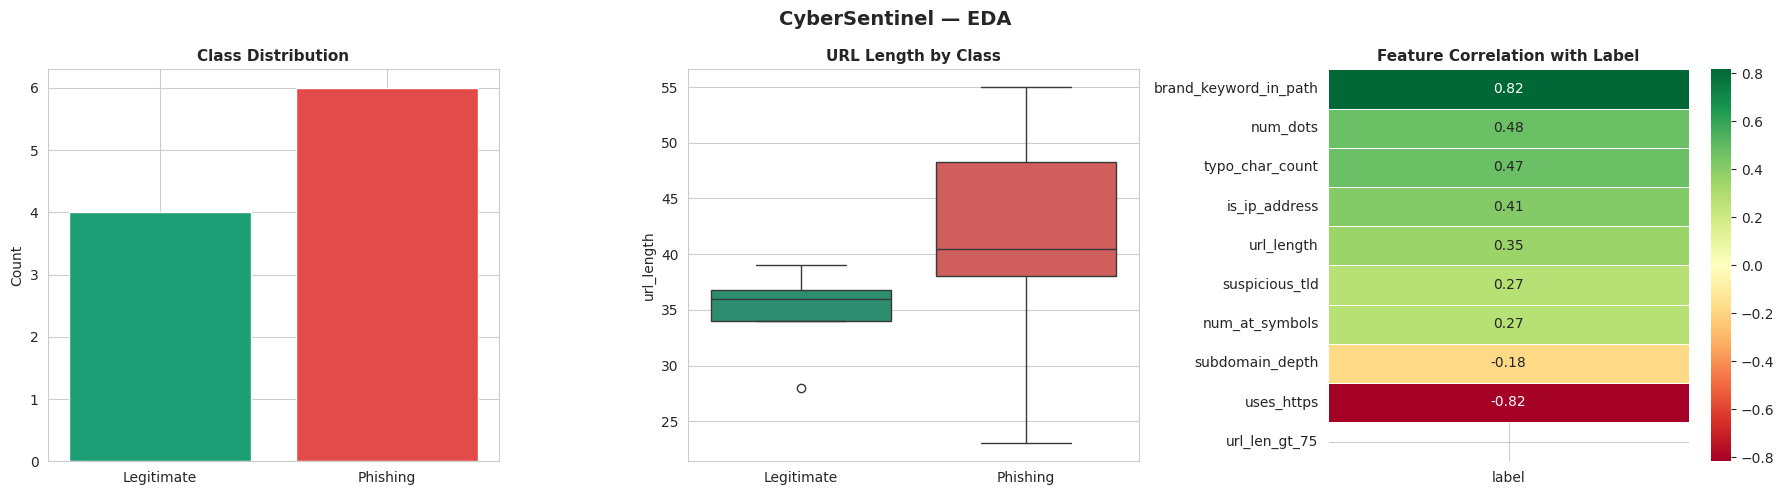

[INFO] EDA plot saved as cybersentinel_eda.png

[Step 4] Splitting data into train and test sets...
         Training samples : 8
         Testing samples  : 2

[Step 5] Training models...

[1/2] Training Random Forest ...
    Random Forest F1: 1.0000 | ROC-AUC: 1.0000
[2/2] Training SVM ...
    SVM F1: 1.0000 | ROC-AUC: 1.0000

[Step 6] Evaluating models...

  Random Forest
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00         1
    Phishing       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2

  ROC-AUC  : 1.0000
  CV F1    : 1.0000 ± 0.0000

  SVM
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00         1
    Phishing       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.

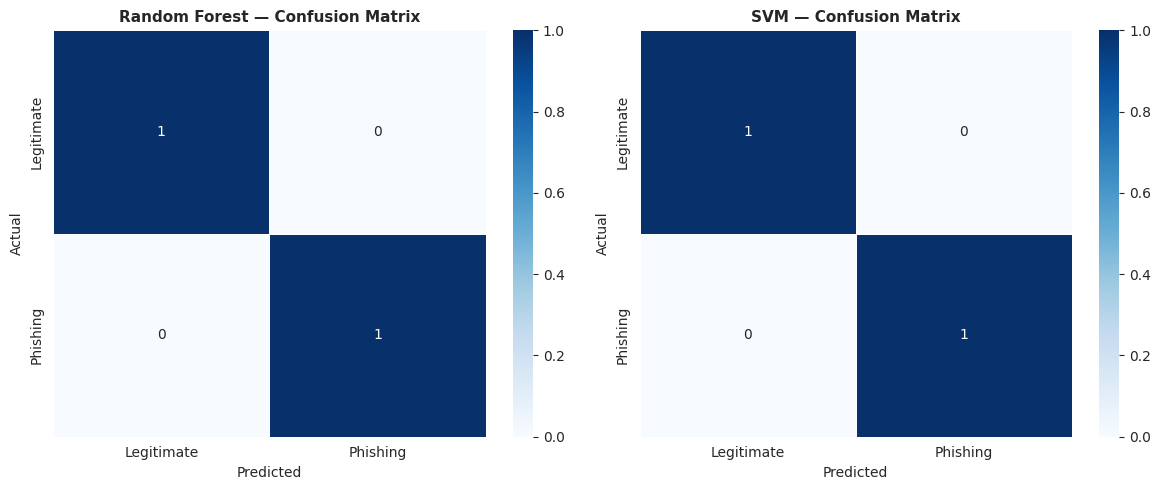

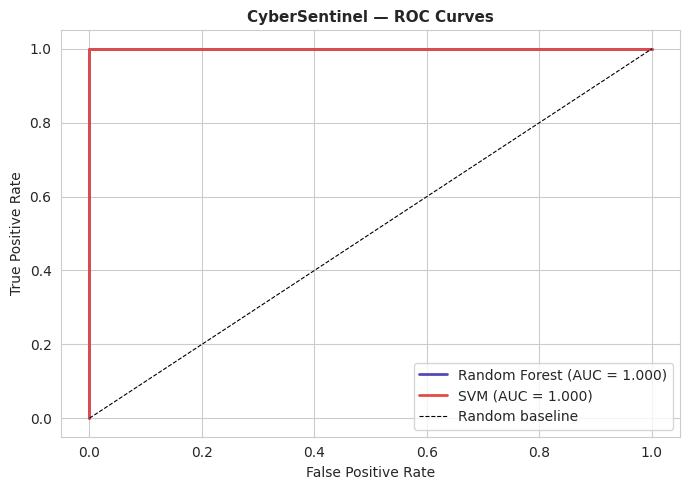

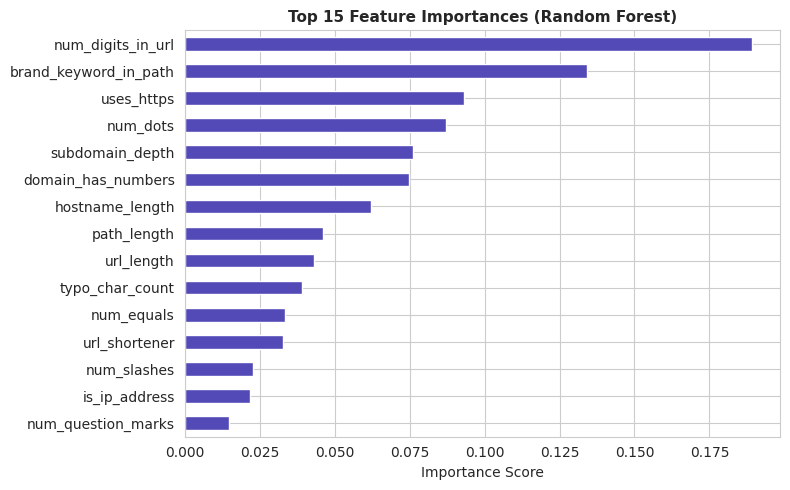


[INFO] Top 5 most important features:
num_digits_in_url        0.189061
brand_keyword_in_path    0.134309
uses_https               0.093309
num_dots                 0.087121
subdomain_depth          0.076109

[Step 7] Running live prediction demo...

  CyberSentinel — Live Prediction Demo

[LEGIT]     26.2% confidence
   URL   : https://www.google.com/search?q=machine+learning
   FLAG  : No suspicious flags found

[PHISHING]  84.6% confidence
   URL   : http://192.168.10.5/paypal/verify/account
   FLAG  : Raw IP address used instead of domain name
   FLAG  : Typosquatting characters found (e.g. 0 instead of o)
   FLAG  : Brand name found in URL path
   FLAG  : No HTTPS — connection is not encrypted

[PHISHING]  75.2% confidence
   URL   : http://secure.g00gle.com.phish.ru@evil.biz/login
   FLAG  : @ symbol in URL — hides real destination
   FLAG  : Brand name found in URL path
   FLAG  : No HTTPS — connection is not encrypted

[LEGIT]     31.4% confidence
   URL   : https://github.com

In [89]:
#  MAIN PIPELINE
#   Run everything step by step
#

if __name__ == '__main__':

    print("=" * 60)
    print("  CyberSentinel — Phishing URL Detector")
    print("=" * 60)

    #
    # Step 1: Load data
    # To use your own dataset: df = load_dataset('your_file.csv')
    #
    print("\n[Step 1] Loading dataset...")
    df = load_dataset()

    #
    # Step 2: Extract features from all URLs
    #
    print("\n[Step 2] Extracting features from URLs...")
    features_df = build_feature_matrix(df['url'].tolist())
    print(f"         Feature matrix shape: {features_df.shape}")
    print(f"         (rows = URLs, columns = features)")

    #
    # Step 3: Explore the data visually
    #
    print("\n[Step 3] Running EDA plots...")
    run_eda(df, features_df)

    #
    # Step 4: Split into training and testing sets
    #
    print("\n[Step 4] Splitting data into train and test sets...")

    X = features_df.values    # feature matrix (all the numbers)
    y = df['label'].values    # labels (0 = legit, 1 = phishing)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,       # 20% for testing, 80% for training
        random_state=42,     # makes the split reproducible
        stratify=y           # keep same class ratio in both splits
    )

    print(f"         Training samples : {len(X_train)}")
    print(f"         Testing samples  : {len(X_test)}")

    #
    # Step 5: Train both models
    #
    print("\n[Step 5] Training models...")
    results = train_models(X_train, X_test, y_train, y_test)

    #
    # Step 6: Evaluate both models
    #
    print("\n[Step 6] Evaluating models...")
    evaluate_models(results, y_test)

    #
    # Step 7: Run live prediction demo
    #
    print("\n[Step 7] Running live prediction demo...")
    best_model = results['Random Forest']['model']
    demo_predictions(best_model)

    #
    # Step 8 (Optional): Hyperparameter tuning
    # Uncomment the lines below if you want to tune the model
    # WARNING: takes 10-20 minutes!
    #
    # print("\n[Step 8] Tuning hyperparameters...")
    # best_model = tune_random_forest(X_train, y_train)

    print("\n[DONE] CyberSentinel pipeline complete!")
    print("       Output files: cybersentinel_eda.png, cybersentinel_confusion.png,")
    print("                     cybersentinel_roc.png, cybersentinel_features.png")


